In [3]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)

# Connexion à la base de données
conn = psycopg2.connect(
    dbname="langdetect_projet",
    user="langdetect_user",
    password="motdepasse",
    host="localhost",
    port="5432"
)

print("Connexion réussie")

Connexion réussie


In [4]:
import warnings
warnings.filterwarnings('ignore')

# Charger tous les articles en mémoire
df = pd.read_sql("SELECT id, langue, longueur FROM documents ORDER BY langue", conn)

print(f"Nombre total d'articles : {len(df)}")
print(f"\nRépartition par langue :")
print(df.groupby('langue')['id'].count().to_string())

Nombre total d'articles : 4000

Répartition par langue :
langue
ar    500
de    500
en    500
es    500
fr    500
nl    500
pt    500
ru    500


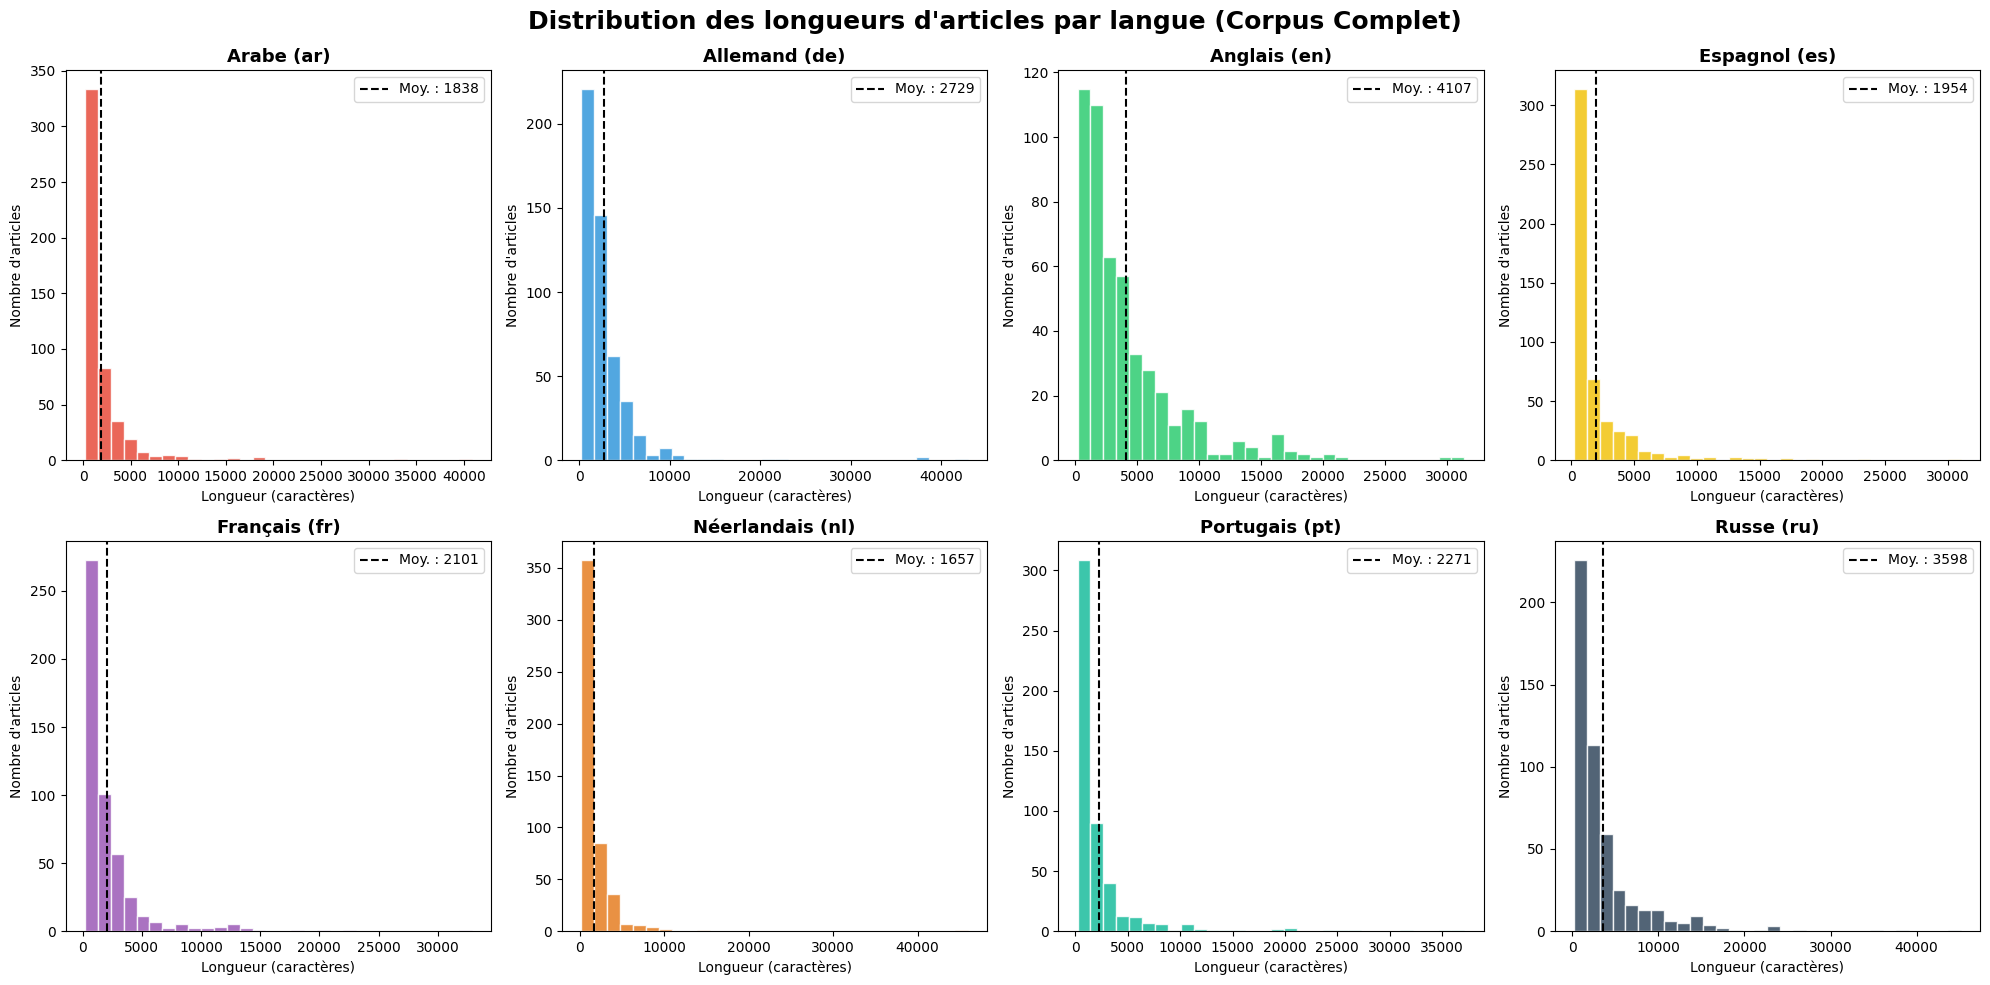

Graphique de distribution sauvegardé


In [5]:
# Distribution des longueurs par langue en grille 2x4
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

# Définition des 8 langues avec des couleurs distinctes
langues_info = [
    ('ar', 'Arabe', '#e74c3c'), ('de', 'Allemand', '#3498db'),
    ('en', 'Anglais', '#2ecc71'), ('es', 'Espagnol', '#f1c40f'),
    ('fr', 'Français', '#9b59b6'), ('nl', 'Néerlandais', '#e67e22'),
    ('pt', 'Portugais', '#1abc9c'), ('ru', 'Russe', '#34495e')
]

for i, (langue, nom, couleur) in enumerate(langues_info):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    data = df[df['langue'] == langue]['longueur']
    ax.hist(data, bins=30, color=couleur, edgecolor='white', alpha=0.85)
    ax.set_title(f'{nom} ({langue})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Longueur (caractères)')
    ax.set_ylabel('Nombre d\'articles')
    ax.axvline(data.mean(), color='black', linestyle='--', linewidth=1.5, label=f'Moy. : {int(data.mean())}')
    ax.legend()

plt.suptitle("Distribution des longueurs d'articles par langue (Corpus Complet)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('distribution_longueurs.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique de distribution sauvegardé")

In [6]:
# Statistiques détaillées par langue
stats = df.groupby('langue')['longueur'].agg(['min', 'max', 'mean', 'median', 'std']).round(0).astype(int)
stats.columns = ['Minimum', 'Maximum', 'Moyenne', 'Médiane', 'Écart-type']

mapping_noms = {
    'ar': 'Arabe', 'de': 'Allemand', 'en': 'Anglais', 'es': 'Espagnol',
    'fr': 'Français', 'nl': 'Néerlandais', 'pt': 'Portugais', 'ru': 'Russe'
}
stats.index = stats.index.map(mapping_noms)

print("=== Statistiques des longueurs d'articles (en caractères) ===\n")
print(stats.to_string())

=== Statistiques des longueurs d'articles (en caractères) ===

             Minimum  Maximum  Moyenne  Médiane  Écart-type
langue                                                     
Arabe            201    40840     1838      713        3394
Allemand         213    42990     2730     1822        3728
Anglais          209    31394     4108     2670        4309
Espagnol         201    31036     1955      726        3140
Français         201    32874     2101     1131        3063
Néerlandais      201    45968     1657     1092        2562
Portugais        201    37134     2271      988        4220
Russe            205    45109     3599     1966        4911


In [7]:
# Analyse des bigrammes les plus fréquents par langue
from collections import Counter

def extraire_bigrammes(texte):
    """Extrait tous les bigrammes de caractères d'un texte."""
    texte = texte.lower()
    return [texte[i:i+2] for i in range(len(texte)-1)]

# Charger les textes complets
df_textes = pd.read_sql("SELECT langue, contenu FROM documents", conn)

print("=== Top 10 des bigrammes par langue ===\n")

for langue, nom, _ in langues_info:
    textes = df_textes[df_textes['langue'] == langue]['contenu']
    compteur = Counter()
    for texte in textes:
        compteur.update(extraire_bigrammes(texte))
    
    print(f"--- {nom} ({langue}) ---")
    for bigramme, freq in compteur.most_common(10):
        print(f"  '{bigramme}' : {freq:,}")
    print()

=== Top 10 des bigrammes par langue ===

--- Arabe (ar) ---
  'ال' : 43,082
  ' ا' : 36,368
  'ة ' : 19,442
  'ي ' : 15,025
  'ن ' : 14,615
  ' م' : 13,305
  ' و' : 11,401
  ' ف' : 8,727
  'في' : 8,636
  'ا ' : 8,535

--- Allemand (de) ---
  'er' : 41,455
  'en' : 34,747
  'n ' : 34,036
  ' d' : 25,576
  'de' : 25,347
  'e ' : 25,105
  'ch' : 24,685
  'r ' : 24,397
  'te' : 20,267
  'ei' : 19,270

--- Anglais (en) ---
  'e ' : 53,663
  ' t' : 44,738
  'th' : 39,367
  ' a' : 38,779
  's ' : 35,962
  'he' : 35,895
  'in' : 33,297
  'd ' : 32,254
  'n ' : 30,823
  'er' : 27,753

--- Espagnol (es) ---
  'e ' : 27,423
  'a ' : 26,221
  ' d' : 21,594
  'de' : 21,475
  ' e' : 18,678
  's ' : 17,870
  'o ' : 17,239
  'n ' : 16,974
  'en' : 16,672
  ' l' : 13,130

--- Français (fr) ---
  'e ' : 44,650
  ' d' : 25,700
  's ' : 24,020
  ' l' : 19,296
  't ' : 18,420
  'es' : 18,054
  'de' : 17,273
  'le' : 15,484
  'en' : 14,761
  'on' : 13,145

--- Néerlandais (nl) ---
  'n ' : 29,519
  'en' : 2

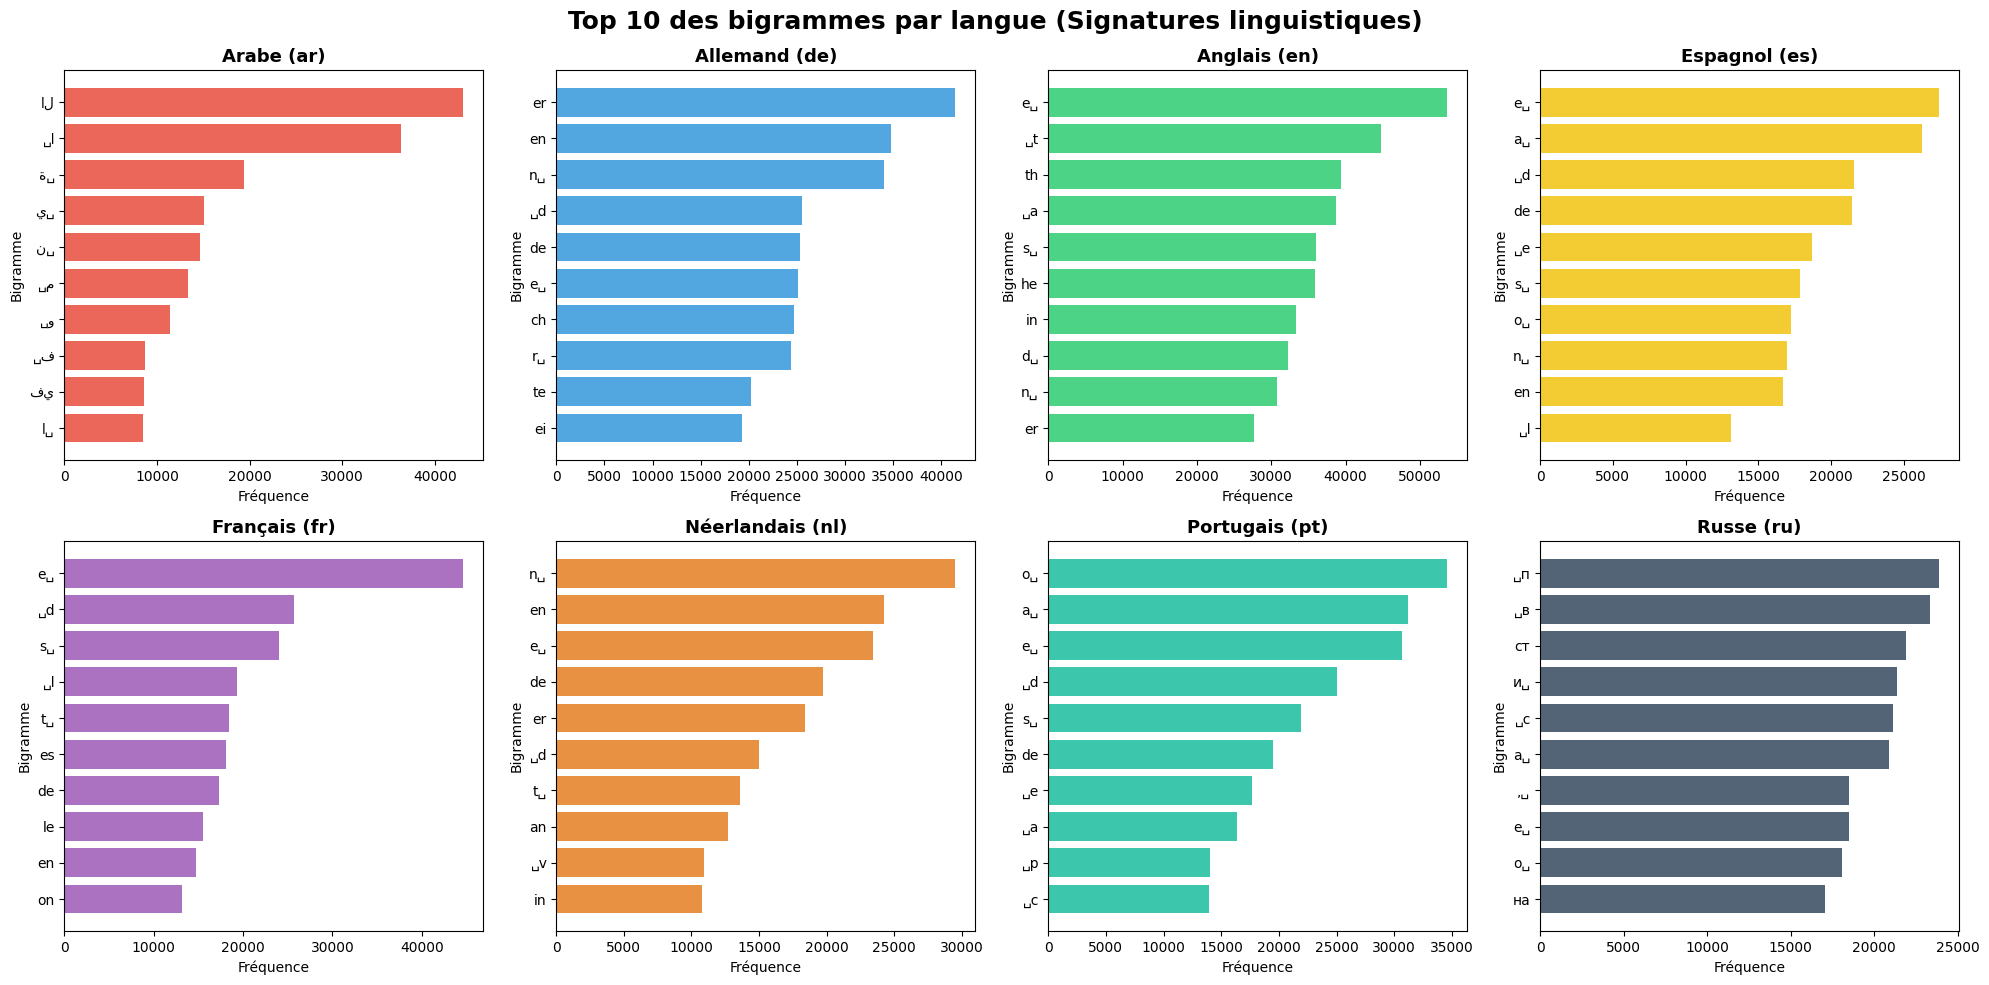

Graphique des bigrammes sauvegardé


In [8]:
# Graphique comparatif des bigrammes en grille 2x4
fig, axes = plt.subplots(2, 4, figsize=(20, 10))

for i, (langue, nom, couleur) in enumerate(langues_info):
    row = i // 4
    col = i % 4
    ax = axes[row, col]
    
    textes = df_textes[df_textes['langue'] == langue]['contenu']
    compteur = Counter()
    for texte in textes:
        compteur.update(extraire_bigrammes(texte))
    
    top10 = compteur.most_common(10)
    # Remplacer les espaces par un symbole visible pour le graphique
    bigrammes = [b[0].replace(' ', '␣').replace('\n', '↵') for b in top10]
    frequences = [b[1] for b in top10]
    
    ax.barh(bigrammes[::-1], frequences[::-1], color=couleur, alpha=0.85)
    ax.set_title(f'{nom} ({langue})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Fréquence')
    ax.set_ylabel('Bigramme')

plt.suptitle("Top 10 des bigrammes par langue (Signatures linguistiques)", fontsize=18, fontweight='bold')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig('bigrammes_top10.png', dpi=150, bbox_inches='tight')
plt.show()
print("Graphique des bigrammes sauvegardé")

In [9]:
# Résumé global du corpus actuel
print("=" * 60)
print("      RÉSUMÉ DU CORPUS FINAL (8 langues)")
print("=" * 60)

total = len(df)
print(f"\nNombre total d'articles : {total}")
print(f"Nombre de langues       : {df['langue'].nunique()}")
print(f"\nDétail par langue :")
print(f"{'Langue':<15} {'Articles':>10} {'Moy. chars':>12} {'Min':>8} {'Max':>8}")
print("-" * 60)

for langue, nom, _ in langues_info:
    subset = df[df['langue'] == langue]['longueur']
    print(f"{nom:<15} {len(subset):>10} {int(subset.mean()):>12} {subset.min():>8} {subset.max():>8}")

print("-" * 60)
print("\nStatut : Corpus complet (8/8 langues).")

      RÉSUMÉ DU CORPUS FINAL (8 langues)

Nombre total d'articles : 4000
Nombre de langues       : 8

Détail par langue :
Langue            Articles   Moy. chars      Min      Max
------------------------------------------------------------
Arabe                  500         1838      201    40840
Allemand               500         2729      213    42990
Anglais                500         4107      209    31394
Espagnol               500         1954      201    31036
Français               500         2101      201    32874
Néerlandais            500         1657      201    45968
Portugais              500         2271      201    37134
Russe                  500         3598      205    45109
------------------------------------------------------------

Statut : Corpus complet (8/8 langues).


In [10]:
# Comptage du nombre de mots par langue
print("=== Nombre de mots par langue ===\n")
print(f"{'Langue':<15} {'Total mots':>12} {'Moy. mots/article':>20}")
print("-" * 55)

for langue, nom, _ in langues_info:
    textes = df_textes[df_textes['langue'] == langue]['contenu']
    nb_mots = textes.apply(lambda t: len(t.split()))
    print(f"{nom:<15} {nb_mots.sum():>12,} {int(nb_mots.mean()):>20}")

print("-" * 55)

=== Nombre de mots par langue ===

Langue            Total mots    Moy. mots/article
-------------------------------------------------------
Arabe                152,818                  305
Allemand             190,354                  380
Anglais              333,010                  666
Espagnol             161,382                  322
Français             171,088                  342
Néerlandais          129,156                  258
Portugais            183,812                  367
Russe                247,735                  495
-------------------------------------------------------


In [11]:
# Vérification des doublons via le checksum
df_checksums = pd.read_sql(
    "SELECT langue, checksum, COUNT(*) as nb FROM documents GROUP BY langue, checksum HAVING COUNT(*) > 1",
    conn
)

print("=== Vérification des doublons ===\n")
if len(df_checksums) == 0:
    print("Aucun doublon détecté dans le corpus.")
else:
    print(f"{len(df_checksums)} doublons détectés :")
    print(df_checksums)

print("\n=== Vérification de l'encodage UTF-8 ===\n")

erreurs_encodage = 0
for langue, nom, _ in langues_info:
    textes = df_textes[df_textes['langue'] == langue]['contenu']
    erreurs = 0
    for texte in textes:
        try:
            texte.encode('utf-8').decode('utf-8')
        except UnicodeDecodeError:
            erreurs += 1
            
    statut = "OK" if erreurs == 0 else f"{erreurs} erreurs"
    print(f"  {nom:<15} : {statut}")
    erreurs_encodage += erreurs

print(f"\nBilan : {'Tout le corpus est en UTF-8 valide.' if erreurs_encodage == 0 else f'{erreurs_encodage} erreurs détectées.'}")

=== Vérification des doublons ===

Aucun doublon détecté dans le corpus.

=== Vérification de l'encodage UTF-8 ===

  Arabe           : OK
  Allemand        : OK
  Anglais         : OK
  Espagnol        : OK
  Français        : OK
  Néerlandais     : OK
  Portugais       : OK
  Russe           : OK

Bilan : Tout le corpus est en UTF-8 valide.


In [13]:
# Résumé des observations - à copier dans le rapport
print("""
=== OBSERVATIONS POUR LE RAPPORT (CORPUS FINAL) ===

1. TAILLE DU CORPUS
   - 8 langues disponibles : arabe, allemand, anglais, espagnol, français, néerlandais, portugais, russe.
   - 500 articles par langue, soit 4 000 articles au total.
   - Le corpus est parfaitement équilibré (pas de biais de représentation inter-classes).
   - Volume total massif : Plus de 1,56 million de mots pour l'apprentissage.

2. DISTRIBUTION DES LONGUEURS
   - La distribution reste fortement asymétrique pour toutes les langues : une majorité d'articles courts avec une longue traîne (jusqu'à ~45 000 caractères pour le russe ou le néerlandais).
   - Les médianes sont systématiquement et nettement inférieures aux moyennes (ex: 713 de médiane contre 1838 de moyenne pour l'arabe), confirmant cette asymétrie.
   - La longueur moyenne varie fortement d'une langue à l'autre (de 1 657 caractères pour le néerlandais à 4 107 caractères pour l'anglais).
   - Tous les articles respectent le filtre de qualité (minimum 200 caractères).

3. QUALITÉ DES DONNÉES
   - L'intégrité est parfaite : aucun doublon détecté (checksum SHA-256) et aucune erreur d'encodage (100% UTF-8 valide).
   - Les alphabets non-latins (cyrillique, arabe) sont correctement gérés et décodés par notre pipeline.

4. SIGNATURES LINGUISTIQUES (N-GRAMMES)
   - L'analyse des bigrammes révèle des signatures très nettes et spécifiques :
     * L'anglais se démarque par le fameux 'th' et ' t'.
     * L'allemand et le néerlandais partagent des terminaisons fortes ('en', 'er').
     * L'espagnol et le portugais sont très proches, mais diffèrent subtilement sur la fréquence du 'o ' (dominant en portugais) et du 'e ' (dominant en espagnol).
     * L'arabe (ex: 'ال' - al) et le russe (ex: 'ст', ' п') se distinguent immédiatement par leurs caractères Unicode uniques.
   - Cette forte variance confirme que notre approche par fréquences de n-grammes est extrêmement pertinente pour discriminer ces 8 classes.
""")


=== OBSERVATIONS POUR LE RAPPORT (CORPUS FINAL) ===

1. TAILLE DU CORPUS
   - 8 langues disponibles : arabe, allemand, anglais, espagnol, français, néerlandais, portugais, russe.
   - 500 articles par langue, soit 4 000 articles au total.
   - Le corpus est parfaitement équilibré (pas de biais de représentation inter-classes).
   - Volume total massif : Plus de 1,56 million de mots pour l'apprentissage.

2. DISTRIBUTION DES LONGUEURS
   - La distribution reste fortement asymétrique pour toutes les langues : une majorité d'articles courts avec une longue traîne (jusqu'à ~45 000 caractères pour le russe ou le néerlandais).
   - Les médianes sont systématiquement et nettement inférieures aux moyennes (ex: 713 de médiane contre 1838 de moyenne pour l'arabe), confirmant cette asymétrie.
   - La longueur moyenne varie fortement d'une langue à l'autre (de 1 657 caractères pour le néerlandais à 4 107 caractères pour l'anglais).
   - Tous les articles respectent le filtre de qualité (minimum 2